# Corners Model (Model Group 4)

Predicts **expected corners for each side** and derives the corner markets from
full count distributions:

- Total corners over 7.5 / 8.5 / 9.5 / 10.5 (and the matching unders)
- Team total corners (home over 4.5/5.5/6.5, away over 3.5/4.5/5.5)

Corners are count data but noticeably **overdispersed** (variance well above the
mean) and style-driven, so the setup differs from goals in two ways:

1. The mean model ladder adds a naive rolling-mean baseline and a **Negative
   Binomial GLM** (statsmodels) - the statistical reference for overdispersed
   counts - with **XGBoost `count:poisson`** as the primary candidate (a Poisson
   objective still estimates the conditional mean consistently under
   overdispersion).
2. Markets come from **NB2 count distributions** (means from the selected model,
   dispersion fitted on training residuals) convolved across the two sides -
   a 2-D Dixon-Coles grid is a goals concept and is not needed here.

The per-side distributions are treated as independent; the empirical residual
correlation is printed below as a known limitation. Shared pipeline code comes
from `src/football_prediction`.

## 1. Configuration

In [1]:
import warnings

import joblib
import numpy
import pandas
import matplotlib.pyplot as pyplot
import statsmodels.api as statsmodels_api
from IPython.display import display
from xgboost import XGBRegressor

from src.football_prediction.core import config
from src.football_prediction.data import loading as data
from src.football_prediction.features import rolling as features
from src.football_prediction.features import state
from src.football_prediction.features.elo import add_elo_features
from src.football_prediction.modeling import calibration, metrics
from src.football_prediction.markets import corners as markets

warnings.filterwarnings("ignore", category=FutureWarning)

artifact_path = config.MODELS_DIRECTORY / "corners_pred.joblib"

random_seed = config.RANDOM_SEED
maximum_side_corners = 25
minimum_expected_corners = 0.5
maximum_expected_corners = 15.0

xgboost_parameters = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "early_stopping_rounds": 50,
    "n_jobs": -1,
    "random_state": random_seed,
}
max_depth_candidates = [3, 4, 5]
min_child_weight_candidates = [1, 5, 10]

# Crossing/territory columns only exist from the 2024-2025 season, so their
# form features ride the NaN-tolerant path.
extra_raw_columns = [
    "home_crosses_attempted_ft",
    "away_crosses_attempted_ft",
    "home_crosses_completed_ft",
    "away_crosses_completed_ft",
    "home_touches_in_opposition_box_ft",
    "away_touches_in_opposition_box_ft",
    "home_shots_inside_box_ft",
    "away_shots_inside_box_ft",
]

own_metrics = {
    "corners_for": "{side}_corner_kicks_ft",
    "points": "{side}_points",
    "total_shots_for": "{side}_total_shots_ft",
    "possession": "{side}_ball_possession_ft",
    "crosses_attempted": "{side}_crosses_attempted_ft",
    "crosses_completed": "{side}_crosses_completed_ft",
    "touches_in_opposition_box": "{side}_touches_in_opposition_box_ft",
    "shots_inside_box": "{side}_shots_inside_box_ft",
}
opponent_metrics = {
    "corners_conceded": "{side}_corner_kicks_ft",
    "total_shots_conceded": "{side}_total_shots_ft",
}
short_rolling_metrics = [
    "corners_for",
    "corners_conceded",
    "total_shots_for",
    "total_shots_conceded",
    "possession",
    "points",
]
long_rolling_metrics = ["corners_for", "corners_conceded"]
nan_tolerant_rolling_metrics = [
    "crosses_attempted",
    "crosses_completed",
    "touches_in_opposition_box",
    "shots_inside_box",
]
venue_rolling_metrics = ["corners_for"]

core_feature_names = [
    "elo_difference",
    "home_elo",
    "away_elo",
    "home_corners_for_form",
    "away_corners_for_form",
    "home_corners_conceded_form",
    "away_corners_conceded_form",
    "home_long_corners_for_form",
    "away_long_corners_for_form",
    "home_long_corners_conceded_form",
    "away_long_corners_conceded_form",
    "home_corners_vs_away_concession",
    "away_corners_vs_home_concession",
    "home_corners_at_home_form",
    "away_corners_at_away_form",
    "home_shots_form",
    "away_shots_form",
    "home_shots_conceded_form",
    "away_shots_conceded_form",
    "possession_difference",
    "points_form_difference",
    "rest_days_difference",
    "is_european_cup",
]
nan_tolerant_feature_names = [
    "home_crosses_attempted_form",
    "away_crosses_attempted_form",
    "home_crosses_completed_form",
    "away_crosses_completed_form",
    "home_touches_in_box_form",
    "away_touches_in_box_form",
    "home_shots_inside_box_form",
    "away_shots_inside_box_form",
]
feature_names = core_feature_names + nan_tolerant_feature_names

total_over_lines = [7.5, 8.5, 9.5, 10.5]
home_over_lines = [4.5, 5.5, 6.5]
away_over_lines = [3.5, 4.5, 5.5]

calibrated_market_names = [
    "total_over_8_5",
    "total_over_9_5",
    "total_over_10_5",
    "home_corners_over_5_5",
    "away_corners_over_4_5",
]
decision_market_names = [
    "total_over_8_5",
    "total_over_9_5",
    "total_over_10_5",
    "total_under_8_5",
    "total_under_9_5",
    "total_under_10_5",
]

pandas.set_option("display.max_columns", 80)
pandas.set_option("display.max_rows", 80)


## 2. Data loading, base rates, and the overdispersion check

The variance/mean ratio of corner counts justifies the Negative Binomial
treatment - for a Poisson it would be 1.

In [2]:
matches, team_match_counts, team_filter_summary, load_summary = data.load_matches(
    extra_columns=extra_raw_columns,
)
matches["total_corners"] = matches["home_corner_kicks_ft"] + matches["away_corner_kicks_ft"]

print("Cleaned dataset shape and date range")
print("Rows and columns:", matches.shape)
print("Date range:", matches["date_utc"].min().date(), "to", matches["date_utc"].max().date())

dispersion_records = []
for column_label, column_name in [
    ("home_corners", "home_corner_kicks_ft"),
    ("away_corners", "away_corner_kicks_ft"),
    ("total_corners", "total_corners"),
]:
    column_mean = float(matches[column_name].mean())
    column_variance = float(matches[column_name].var())
    dispersion_records.append({
        "count": column_label,
        "mean": column_mean,
        "variance": column_variance,
        "variance_over_mean": column_variance / column_mean,
    })
dispersion_table = pandas.DataFrame(dispersion_records)
print("\nOverdispersion check (variance/mean > 1 motivates the Negative Binomial)")
display(dispersion_table.round(3))
assert (dispersion_table["variance_over_mean"] > 1.0).all(), "corners are not overdispersed-"

print("\nCorner market base rates and train-relevant quantiles")
base_rate_records = {"mean_total_corners": matches["total_corners"].mean()}
for line in total_over_lines:
    base_rate_records[f"total_over_{str(line).replace('.', '_')}_rate"] = (
        matches["total_corners"] > line
    ).mean()
display(pandas.DataFrame([base_rate_records]).round(3))
print("Quantiles of per-side corners (sanity for the team lines)")
display(
    matches[["home_corner_kicks_ft", "away_corner_kicks_ft", "total_corners"]]
    .quantile([0.25, 0.5, 0.75])
    .round(2)
)


Cleaned dataset shape and date range
Rows and columns: (14721, 45)
Date range: 2020-08-18 to 2026-05-30

Overdispersion check (variance/mean > 1 motivates the Negative Binomial)


,count,mean,variance,variance_over_mean
0,home_corners,5.297,8.773,1.656
1,away_corners,4.249,6.731,1.584
2,total_corners,9.545,11.347,1.189



Corner market base rates and train-relevant quantiles


,mean_total_corners,total_over_7_5_rate,total_over_8_5_rate,total_over_9_5_rate,total_over_10_5_rate
0,9.545,0.713,0.599,0.481,0.367


Quantiles of per-side corners (sanity for the team lines)


,home_corner_kicks_ft,away_corner_kicks_ft,total_corners
0.25,3.0,2.0,7.0
0.50,5.0,4.0,9.0
0.75,7.0,6.0,12.0


## 3. Feature table (leakage-safe rolling style and territory form)

In [3]:
def build_corners_feature_table(match_frame):
    matches_with_elo, final_team_ratings = add_elo_features(match_frame)
    team_match_rows = features.make_team_match_rows(
        matches_with_elo,
        own_metrics=own_metrics,
        opponent_metrics=opponent_metrics,
        ratio_metrics={},
    )
    rolling_team_form = features.add_rolling_team_form(
        team_match_rows,
        short_metrics=short_rolling_metrics,
        long_metrics=long_rolling_metrics,
        nan_tolerant_metrics=nan_tolerant_rolling_metrics,
        venue_metrics=venue_rolling_metrics,
    )
    form_columns = features.form_column_names(
        short_rolling_metrics,
        long_rolling_metrics,
        nan_tolerant_rolling_metrics,
        venue_rolling_metrics,
    )
    feature_table = features.merge_side_form(matches_with_elo, rolling_team_form, form_columns)

    feature_table["home_corners_for_form"] = feature_table["home_rolling_corners_for"]
    feature_table["away_corners_for_form"] = feature_table["away_rolling_corners_for"]
    feature_table["home_corners_conceded_form"] = feature_table["home_rolling_corners_conceded"]
    feature_table["away_corners_conceded_form"] = feature_table["away_rolling_corners_conceded"]
    feature_table["home_long_corners_for_form"] = feature_table["home_long_rolling_corners_for"]
    feature_table["away_long_corners_for_form"] = feature_table["away_long_rolling_corners_for"]
    feature_table["home_long_corners_conceded_form"] = feature_table["home_long_rolling_corners_conceded"]
    feature_table["away_long_corners_conceded_form"] = feature_table["away_long_rolling_corners_conceded"]
    feature_table["home_corners_vs_away_concession"] = (
        feature_table["home_rolling_corners_for"] - feature_table["away_rolling_corners_conceded"]
    )
    feature_table["away_corners_vs_home_concession"] = (
        feature_table["away_rolling_corners_for"] - feature_table["home_rolling_corners_conceded"]
    )
    feature_table["home_corners_at_home_form"] = feature_table["home_rolling_corners_for_at_venue"]
    feature_table["away_corners_at_away_form"] = feature_table["away_rolling_corners_for_at_venue"]
    feature_table["home_shots_form"] = feature_table["home_rolling_total_shots_for"]
    feature_table["away_shots_form"] = feature_table["away_rolling_total_shots_for"]
    feature_table["home_shots_conceded_form"] = feature_table["home_rolling_total_shots_conceded"]
    feature_table["away_shots_conceded_form"] = feature_table["away_rolling_total_shots_conceded"]
    feature_table["possession_difference"] = (
        feature_table["home_rolling_possession"] - feature_table["away_rolling_possession"]
    )
    feature_table["points_form_difference"] = (
        feature_table["home_rolling_points"] - feature_table["away_rolling_points"]
    )
    feature_table["rest_days_difference"] = (
        feature_table["home_rest_days"] - feature_table["away_rest_days"]
    )

    feature_table["home_crosses_attempted_form"] = feature_table["home_rolling_crosses_attempted"]
    feature_table["away_crosses_attempted_form"] = feature_table["away_rolling_crosses_attempted"]
    feature_table["home_crosses_completed_form"] = feature_table["home_rolling_crosses_completed"]
    feature_table["away_crosses_completed_form"] = feature_table["away_rolling_crosses_completed"]
    feature_table["home_touches_in_box_form"] = feature_table["home_rolling_touches_in_opposition_box"]
    feature_table["away_touches_in_box_form"] = feature_table["away_rolling_touches_in_opposition_box"]
    feature_table["home_shots_inside_box_form"] = feature_table["home_rolling_shots_inside_box"]
    feature_table["away_shots_inside_box_form"] = feature_table["away_rolling_shots_inside_box"]

    return feature_table, team_match_rows, rolling_team_form, final_team_ratings


feature_table, team_match_rows, rolling_team_form, final_team_ratings = (
    build_corners_feature_table(matches)
)
model_data = feature_table.dropna(subset=core_feature_names).copy()

example_team = rolling_team_form["team"].iloc[0]
example_history = rolling_team_form[rolling_team_form["team"].eq(example_team)].sort_values(
    ["date_utc", "match_id"]
)
check_position = 10
manual_mean = example_history["corners_for"].iloc[check_position - 5:check_position].mean()
assert abs(example_history["rolling_corners_for"].iloc[check_position] - manual_mean) < 1e-12
print(f"Leakage spot-check passed: rolling_corners_for for {example_team} equals "
      f"the mean of its previous 5 matches ({manual_mean:.3f})")

print("\nFeature build summary")
display(pandas.DataFrame([{
    "rows_before_dropping_no_history_rows": len(feature_table),
    "rows_after_dropping_no_history_rows": len(model_data),
    "rows_dropped": len(feature_table) - len(model_data),
    "core_features": len(core_feature_names),
    "missing_tolerant_features": len(nan_tolerant_feature_names),
    "total_features": len(feature_names),
}]))

print("\nMissing-tolerant feature availability (share of modelled rows with a value)")
display(
    model_data[nan_tolerant_feature_names].notna().mean().rename("available").round(3).to_frame()
)


Leakage spot-check passed: rolling_corners_for for linfield equals the mean of its previous 5 matches (5.400)

Feature build summary


,rows_before_dropping_no_history_rows,rows_after_dropping_no_history_rows,rows_dropped,core_features,missing_tolerant_features,total_features
0,14721,12475,2246,23,8,31



Missing-tolerant feature availability (share of modelled rows with a value)


,available
home_crosses_attempted_form,0.282
away_crosses_attempted_form,0.284
home_crosses_completed_form,0.282
away_crosses_completed_form,0.284
home_touches_in_box_form,0.282
away_touches_in_box_form,0.284
home_shots_inside_box_form,0.282
away_shots_inside_box_form,0.284


## 4. Temporal split (same dates as every other model group)

In [4]:
training_matches = model_data[model_data["date_utc"] < config.VALIDATION_SPLIT_DATE].copy()
validation_matches = model_data[
    (model_data["date_utc"] >= config.VALIDATION_SPLIT_DATE)
    & (model_data["date_utc"] < config.TEST_SPLIT_DATE)
].copy()
test_matches = model_data[model_data["date_utc"] >= config.TEST_SPLIT_DATE].copy()

split_summary = pandas.DataFrame([
    {
        "split": split_name,
        "rows": len(split_frame),
        "start": split_frame["date_utc"].min().date(),
        "end": split_frame["date_utc"].max().date(),
        "mean_home_corners": split_frame["home_corner_kicks_ft"].mean(),
        "mean_away_corners": split_frame["away_corner_kicks_ft"].mean(),
        "total_over_9_5_rate": (split_frame["total_corners"] > 9.5).mean(),
    }
    for split_name, split_frame in [
        ("training", training_matches),
        ("validation", validation_matches),
        ("test", test_matches),
    ]
])
print("Temporal three-way split summary")
print(f"Validation from {config.VALIDATION_SPLIT_DATE.date()}, test from {config.TEST_SPLIT_DATE.date()}")
display(split_summary.round(3))

training_feature_matrix = training_matches[feature_names]
validation_feature_matrix = validation_matches[feature_names]
test_feature_matrix = test_matches[feature_names]


Temporal three-way split summary
Validation from 2025-07-01, test from 2026-01-01


,split,rows,start,end,mean_home_corners,mean_away_corners,total_over_9_5_rate
0,training,10072,2020-11-05,2025-05-31,5.310,4.307,0.490
1,validation,1251,2025-07-08,2025-12-30,5.265,4.111,0.469
2,test,1152,2026-01-01,2026-05-30,5.347,4.161,0.486


## 5. Model ladder

Four rungs per side: constant league mean, the naive rolling-mean form baseline
the model must beat, a Negative Binomial GLM on standardized core features, and
XGBoost `count:poisson` with the usual validation sweep.

In [5]:
side_targets = {"home": "home_corner_kicks_ft", "away": "away_corner_kicks_ft"}
rolling_mean_feature = {"home": "home_corners_for_form", "away": "away_corners_for_form"}

constant_corner_means = {
    side_name: float(training_matches[target_column].mean())
    for side_name, target_column in side_targets.items()
}
print(f"Constant baseline expected corners: {constant_corner_means}")

# Negative Binomial GLM on standardized core features. The NB2 alpha comes from
# a Poisson GLM first (Cameron-Trivedi moment estimator on its residuals).
core_feature_means = training_matches[core_feature_names].mean()
core_feature_stds = training_matches[core_feature_names].std().replace(0.0, 1.0)


def standardized_design_matrix(split_frame):
    standardized = (split_frame[core_feature_names] - core_feature_means) / core_feature_stds
    return statsmodels_api.add_constant(standardized.to_numpy(), has_constant="add")


def cameron_trivedi_alpha(observed_counts, fitted_means):
    observed_counts = numpy.asarray(observed_counts, dtype=float)
    fitted_means = numpy.asarray(fitted_means, dtype=float)
    numerator = float(((observed_counts - fitted_means) ** 2 - observed_counts).sum())
    denominator = float((fitted_means ** 2).sum())
    return max(numerator / denominator, 1e-6)


negbin_glm_models = {}
negbin_glm_alphas = {}
for side_name, target_column in side_targets.items():
    training_design = standardized_design_matrix(training_matches)
    poisson_fit = statsmodels_api.GLM(
        training_matches[target_column].to_numpy(),
        training_design,
        family=statsmodels_api.families.Poisson(),
    ).fit()
    glm_alpha = cameron_trivedi_alpha(
        training_matches[target_column].to_numpy(), poisson_fit.mu,
    )
    negbin_fit = statsmodels_api.GLM(
        training_matches[target_column].to_numpy(),
        training_design,
        family=statsmodels_api.families.NegativeBinomial(alpha=glm_alpha),
    ).fit()
    negbin_glm_models[side_name] = negbin_fit
    negbin_glm_alphas[side_name] = glm_alpha
print(f"Negative Binomial GLM alphas (from Poisson-GLM residuals): "
      f"home {negbin_glm_alphas['home']:.4f}, away {negbin_glm_alphas['away']:.4f}")


def fit_count_model(target_column, max_depth_value, min_child_weight_value):
    count_model = XGBRegressor(
        **xgboost_parameters,
        objective="count:poisson",
        eval_metric="poisson-nloglik",
        max_depth=max_depth_value,
        min_child_weight=min_child_weight_value,
    )
    count_model.fit(
        training_feature_matrix,
        training_matches[target_column],
        eval_set=[(validation_feature_matrix, validation_matches[target_column])],
        verbose=False,
    )
    return count_model


sweep_records = []
best_sweep_record = None
best_sweep_models = None
for max_depth_value in max_depth_candidates:
    for min_child_weight_value in min_child_weight_candidates:
        candidate_models = {
            side_name: fit_count_model(target_column, max_depth_value, min_child_weight_value)
            for side_name, target_column in side_targets.items()
        }
        side_deviances = {}
        for side_name, target_column in side_targets.items():
            predicted_mu = numpy.clip(
                candidate_models[side_name].predict(validation_feature_matrix),
                minimum_expected_corners,
                maximum_expected_corners,
            )
            side_deviances[side_name] = metrics.count_metrics(
                validation_matches[target_column], predicted_mu
            )["poisson_deviance"]
        sweep_record = {
            "max_depth": max_depth_value,
            "min_child_weight": min_child_weight_value,
            "home_poisson_deviance": side_deviances["home"],
            "away_poisson_deviance": side_deviances["away"],
            "mean_poisson_deviance": (side_deviances["home"] + side_deviances["away"]) / 2.0,
        }
        sweep_records.append(sweep_record)
        if (
            best_sweep_record is None
            or sweep_record["mean_poisson_deviance"] < best_sweep_record["mean_poisson_deviance"]
        ):
            best_sweep_record = sweep_record
            best_sweep_models = candidate_models

sweep_table = pandas.DataFrame(sweep_records).sort_values("mean_poisson_deviance").reset_index(drop=True)
print("\nValidation sweep (sorted by mean validation Poisson deviance)")
display(sweep_table.round(4))

best_max_depth = best_sweep_record["max_depth"]
best_min_child_weight = best_sweep_record["min_child_weight"]
xgboost_corner_models = best_sweep_models
print(f"\nSelected configuration: max_depth={best_max_depth}, min_child_weight={best_min_child_weight}")


def expected_corners_for_family(family_name, split_frame):
    side_mus = {}
    for side_name in ["home", "away"]:
        if family_name == "constant_league_mean":
            side_mu = numpy.full(len(split_frame), constant_corner_means[side_name])
        elif family_name == "rolling_mean_form":
            side_mu = split_frame[rolling_mean_feature[side_name]].to_numpy(dtype=float)
        elif family_name == "negbin_glm":
            side_mu = negbin_glm_models[side_name].predict(standardized_design_matrix(split_frame))
        elif family_name == "xgboost_count_poisson":
            side_mu = xgboost_corner_models[side_name].predict(split_frame[feature_names])
        else:
            raise ValueError(f"Unknown model family {family_name!r}")
        side_mus[side_name] = numpy.clip(side_mu, minimum_expected_corners, maximum_expected_corners)
    return side_mus["home"], side_mus["away"]


family_records = []
for family_name in ["constant_league_mean", "rolling_mean_form", "negbin_glm", "xgboost_count_poisson"]:
    validation_home_mu, validation_away_mu = expected_corners_for_family(family_name, validation_matches)
    home_metrics = metrics.count_metrics(validation_matches["home_corner_kicks_ft"], validation_home_mu)
    away_metrics = metrics.count_metrics(validation_matches["away_corner_kicks_ft"], validation_away_mu)
    family_records.append({
        "family": family_name,
        "home_mae": home_metrics["mae"],
        "away_mae": away_metrics["mae"],
        "home_poisson_deviance": home_metrics["poisson_deviance"],
        "away_poisson_deviance": away_metrics["poisson_deviance"],
        "mean_poisson_deviance": (home_metrics["poisson_deviance"] + away_metrics["poisson_deviance"]) / 2.0,
    })

family_table = pandas.DataFrame(family_records).sort_values("mean_poisson_deviance").reset_index(drop=True)
print("\nModel family comparison on the validation window")
display(family_table.round(4))

selected_model_family = family_table.iloc[0]["family"]
rolling_mean_row = family_table[family_table["family"].eq("rolling_mean_form")].iloc[0]
selected_row = family_table.iloc[0]
if selected_model_family == "rolling_mean_form":
    print("\nWARNING: nothing beat the naive rolling-mean baseline on validation - "
          "shipping the baseline honestly.")
else:
    print(f"\nSelected model family: {selected_model_family} "
          f"(validation MAE home {selected_row['home_mae']:.3f} vs rolling-mean "
          f"{rolling_mean_row['home_mae']:.3f})")


def predict_expected_corners(split_frame):
    return expected_corners_for_family(selected_model_family, split_frame)


Constant baseline expected corners: {'home': 5.309868943606037, 'away': 4.30659253375695}
Negative Binomial GLM alphas (from Poisson-GLM residuals): home 0.0839, away 0.0916

Validation sweep (sorted by mean validation Poisson deviance)


,max_depth,min_child_weight,home_poisson_deviance,away_poisson_deviance,mean_poisson_deviance
0,3,1,1.5727,1.5107,1.5417
1,3,5,1.5727,1.5107,1.5417
2,3,10,1.5737,1.5117,1.5427
3,4,1,1.5748,1.5155,1.5451
4,4,5,1.5748,1.5155,1.5451
5,4,10,1.5763,1.5155,1.5459
6,5,1,1.5753,1.5224,1.5489
7,5,5,1.5753,1.5224,1.5489
8,5,10,1.5764,1.5219,1.5492



Selected configuration: max_depth=3, min_child_weight=1

Model family comparison on the validation window


,family,home_mae,away_mae,home_poisson_deviance,away_poisson_deviance,mean_poisson_deviance
0,xgboost_count_poisson,2.2608,1.9114,1.5727,1.5107,1.5417
1,negbin_glm,2.2646,1.9112,1.5712,1.5130,1.5421
2,constant_league_mean,2.3760,1.9821,1.7123,1.6239,1.6681
3,rolling_mean_form,2.4859,2.2470,2.0492,1.9268,1.9880



Selected model family: xgboost_count_poisson (validation MAE home 2.261 vs rolling-mean 2.486)


## 6. Count distributions: NB2 dispersion, convolution, and market derivation

The selected model provides the means; the NB2 dispersion alpha is re-estimated
per side from that model's training residuals (Cameron-Trivedi). Per-side pmfs
are convolved into the total-corners distribution. A log-score comparison shows
why the NB2 shape beats a plain Poisson at the same means.

In [6]:
training_home_mu, training_away_mu = predict_expected_corners(training_matches)
distribution_alphas = {
    "home": cameron_trivedi_alpha(training_matches["home_corner_kicks_ft"], training_home_mu),
    "away": cameron_trivedi_alpha(training_matches["away_corner_kicks_ft"], training_away_mu),
}
print(f"NB2 dispersion alphas on the selected model's training residuals: "
      f"home {distribution_alphas['home']:.4f}, away {distribution_alphas['away']:.4f}")

home_residuals = training_matches["home_corner_kicks_ft"].to_numpy() - training_home_mu
away_residuals = training_matches["away_corner_kicks_ft"].to_numpy() - training_away_mu
residual_correlation = float(numpy.corrcoef(home_residuals, away_residuals)[0, 1])
print(f"Per-side residual correlation on training: {residual_correlation:.4f} "
      "(the convolution assumes independence; this is a known limitation)")


def build_corner_pmfs(split_frame, dispersion=None):
    home_mu, away_mu = predict_expected_corners(split_frame)
    home_alpha = distribution_alphas["home"] if dispersion is None else dispersion
    away_alpha = distribution_alphas["away"] if dispersion is None else dispersion
    home_pmf = markets.count_pmf_vector(home_mu, maximum_side_corners, dispersion=home_alpha)
    away_pmf = markets.count_pmf_vector(away_mu, maximum_side_corners, dispersion=away_alpha)
    total_pmf = markets.convolve_pmfs(home_pmf, away_pmf)
    return home_pmf, away_pmf, total_pmf


def line_column(prefix, line):
    return f"{prefix}_{str(line).replace('.', '_')}"


def derive_corner_markets(home_pmf, away_pmf, total_pmf):
    market_frame = pandas.DataFrame()
    for line in total_over_lines:
        market_frame[line_column("total_over", line)] = markets.pmf_over(total_pmf, line)
    for line in home_over_lines:
        market_frame[line_column("home_corners_over", line)] = markets.pmf_over(home_pmf, line)
    for line in away_over_lines:
        market_frame[line_column("away_corners_over", line)] = markets.pmf_over(away_pmf, line)
    return market_frame


def market_outcome(match_frame, market_name):
    if market_name.startswith("total_over_"):
        line = float(market_name[len("total_over_"):].replace("_", "."))
        return (match_frame["total_corners"] > line).astype(int)
    if market_name.startswith("total_under_"):
        line = float(market_name[len("total_under_"):].replace("_", "."))
        return (match_frame["total_corners"] < line).astype(int)
    if market_name.startswith("home_corners_over_"):
        line = float(market_name[len("home_corners_over_"):].replace("_", "."))
        return (match_frame["home_corner_kicks_ft"] > line).astype(int)
    if market_name.startswith("away_corners_over_"):
        line = float(market_name[len("away_corners_over_"):].replace("_", "."))
        return (match_frame["away_corner_kicks_ft"] > line).astype(int)
    raise ValueError(f"Unknown market {market_name!r}")


training_home_pmf, training_away_pmf, training_total_pmf = build_corner_pmfs(training_matches)
validation_home_pmf, validation_away_pmf, validation_total_pmf = build_corner_pmfs(validation_matches)
test_home_pmf, test_away_pmf, test_total_pmf = build_corner_pmfs(test_matches)

for split_name, total_pmf in [
    ("training", training_total_pmf),
    ("validation", validation_total_pmf),
    ("test", test_total_pmf),
]:
    assert numpy.allclose(total_pmf.sum(axis=1), 1.0), f"{split_name} total pmf does not sum to 1"
print("Convolved total-corner distributions sum to 1 on every split")

training_market_frame = derive_corner_markets(training_home_pmf, training_away_pmf, training_total_pmf)
validation_market_frame = derive_corner_markets(
    validation_home_pmf, validation_away_pmf, validation_total_pmf,
)
test_market_frame = derive_corner_markets(test_home_pmf, test_away_pmf, test_total_pmf)

sanity_records = []
for market_name in ["total_over_9_5", "home_corners_over_5_5"]:
    mean_predicted = float(training_market_frame[market_name].mean())
    empirical_rate = float(market_outcome(training_matches, market_name).mean())
    sanity_records.append({
        "market": market_name,
        "mean_predicted_train": mean_predicted,
        "empirical_rate_train": empirical_rate,
        "gap": mean_predicted - empirical_rate,
    })
    assert abs(mean_predicted - empirical_rate) < 0.05, f"{market_name} calibration drift too large"
print("\nTraining-window sanity check: mean derived probability vs empirical rate")
display(pandas.DataFrame(sanity_records).round(4))

# NB2 vs plain Poisson at the same means: mean log-score of the realized counts
# on the validation window (higher is better).
poisson_validation_home_pmf, poisson_validation_away_pmf, _ = build_corner_pmfs(
    validation_matches, dispersion=0.0,
)
log_score_records = []
for distribution_label, side_pmfs in [
    ("nb2", (validation_home_pmf, validation_away_pmf)),
    ("poisson", (poisson_validation_home_pmf, poisson_validation_away_pmf)),
]:
    for side_name, side_pmf in zip(["home", "away"], side_pmfs):
        observed_counts = validation_matches[side_targets[side_name]].to_numpy().astype(int)
        observed_counts = numpy.clip(observed_counts, 0, maximum_side_corners)
        realized_probabilities = side_pmf[numpy.arange(len(observed_counts)), observed_counts]
        log_score_records.append({
            "distribution": distribution_label,
            "side": side_name,
            "mean_log_score": float(numpy.log(numpy.clip(realized_probabilities, 1e-12, None)).mean()),
        })
log_score_table = pandas.DataFrame(log_score_records).pivot(
    index="side", columns="distribution", values="mean_log_score",
)
log_score_table["nb2_advantage"] = log_score_table["nb2"] - log_score_table["poisson"]
print("\nNB2 vs Poisson mean log-score on validation (positive advantage = NB2 fits better)")
display(log_score_table.round(4))


NB2 dispersion alphas on the selected model's training residuals: home 0.0738, away 0.0807
Per-side residual correlation on training: -0.2033 (the convolution assumes independence; this is a known limitation)
Convolved total-corner distributions sum to 1 on every split

Training-window sanity check: mean derived probability vs empirical rate


,market,mean_predicted_train,empirical_rate_train,gap
0,total_over_9_5,0.4795,0.490,-0.0105
1,home_corners_over_5_5,0.4229,0.421,0.0019



NB2 vs Poisson mean log-score on validation (positive advantage = NB2 fits better)


distribution,nb2,poisson,nb2_advantage
side,,,
away,-2.2422,-2.2747,0.0325
home,-2.4073,-2.4548,0.0475


## 7. Market calibration

Validation market metrics before and after calibration (in-sample for the calibrators)


,market,rows,log_loss,brier,mean_predicted,empirical_rate
0,total_over_8_5 (raw),1251,0.6781,0.2426,0.5842,0.5795
1,total_over_9_5 (raw),1251,0.6910,0.2489,0.4732,0.4692
2,total_over_10_5 (raw),1251,0.6529,0.2301,0.3690,0.3581
3,home_corners_over_5_5 (raw),1251,0.6479,0.2280,0.4182,0.4221
4,away_corners_over_4_5 (raw),1251,0.6462,0.2272,0.4126,0.3845
5,total_over_8_5 (calibrated),1251,0.6779,0.2425,0.5796,0.5795
6,total_over_9_5 (calibrated),1251,0.6900,0.2484,0.4692,0.4692
7,total_over_10_5 (calibrated),1251,0.6513,0.2294,0.3581,0.3581
8,home_corners_over_5_5 (calibrated),1251,0.6479,0.2280,0.4220,0.4221
9,away_corners_over_4_5 (calibrated),1251,0.6437,0.2260,0.3845,0.3845


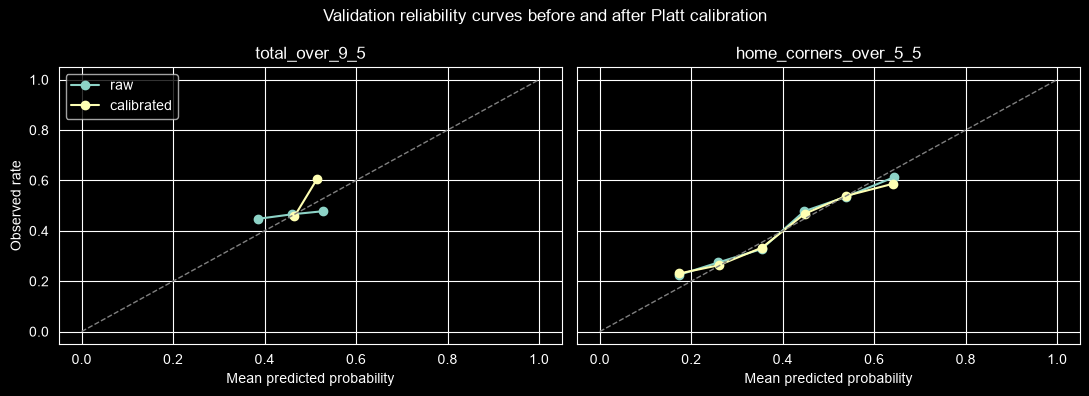

In [7]:
market_calibrators = {}
for market_name in calibrated_market_names:
    market_calibrators[market_name] = calibration.fit_binary_platt(
        validation_market_frame[market_name].to_numpy(),
        market_outcome(validation_matches, market_name).to_numpy(),
    )


def apply_market_calibration(market_frame):
    calibrated_frame = market_frame.copy()
    for market_name, market_calibrator in market_calibrators.items():
        calibrated_frame[market_name] = calibration.apply_binary_calibration(
            market_frame[market_name].to_numpy(), market_calibrator,
        )
    return calibrated_frame


validation_calibrated_market_frame = apply_market_calibration(validation_market_frame)

validation_market_eval = metrics.market_eval_table({
    **{
        f"{market_name} (raw)": (
            validation_market_frame[market_name].to_numpy(),
            market_outcome(validation_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
    **{
        f"{market_name} (calibrated)": (
            validation_calibrated_market_frame[market_name].to_numpy(),
            market_outcome(validation_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
})
print("Validation market metrics before and after calibration "
      "(in-sample for the calibrators)")
display(validation_market_eval.round(4))

figure, axes = pyplot.subplots(1, 2, figsize=(11, 4), sharey=True)
for market_name, axis in zip(["total_over_9_5", "home_corners_over_5_5"], axes):
    outcome_indicator = market_outcome(validation_matches, market_name).to_numpy().astype(float)
    for curve_label, probability_values in [
        ("raw", validation_market_frame[market_name].to_numpy()),
        ("calibrated", validation_calibrated_market_frame[market_name].to_numpy()),
    ]:
        curve_table = calibration.reliability_table(probability_values, outcome_indicator)
        axis.plot(curve_table["mean_predicted"], curve_table["observed_rate"], marker="o", label=curve_label)
    axis.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axis.set_title(market_name)
    axis.set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed rate")
axes[0].legend()
figure.suptitle("Validation reliability curves before and after Platt calibration")
pyplot.tight_layout()
pyplot.show()


## 8. Decision layer and threshold tuning

In [8]:
def decision_probability_frame(calibrated_market_frame):
    decision_frame = pandas.DataFrame(index=calibrated_market_frame.index)
    for market_name in decision_market_names:
        if market_name.startswith("total_under_"):
            over_name = market_name.replace("total_under_", "total_over_")
            decision_frame[market_name] = 1.0 - calibrated_market_frame[over_name]
        else:
            decision_frame[market_name] = calibrated_market_frame[market_name]
    return decision_frame


threshold_candidates = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
minimum_pick_coverage = 0.15

validation_decision_probabilities = decision_probability_frame(validation_calibrated_market_frame)

threshold_tuning_records = []
decision_thresholds = {}
for market_name in decision_market_names:
    market_probabilities = validation_decision_probabilities[market_name].to_numpy()
    market_outcomes = market_outcome(validation_matches, market_name).to_numpy()
    market_rows = []
    for threshold in threshold_candidates:
        picked = market_probabilities >= threshold
        market_rows.append({
            "market": market_name,
            "threshold": threshold,
            "picks": int(picked.sum()),
            "coverage": float(picked.mean()),
            "precision": float(market_outcomes[picked].mean()) if picked.any() else numpy.nan,
        })
    market_tuning = pandas.DataFrame(market_rows)
    threshold_tuning_records.append(market_tuning)
    eligible = market_tuning[market_tuning["coverage"] >= minimum_pick_coverage]
    if eligible.empty:
        eligible = market_tuning[market_tuning["picks"] > 0]
    if eligible.empty:
        # No threshold ever picks a match; park the market at the strictest cut.
        decision_thresholds[market_name] = float(max(threshold_candidates))
    else:
        selected = eligible.sort_values(["precision", "coverage"], ascending=False).iloc[0]
        decision_thresholds[market_name] = float(selected["threshold"])

threshold_tuning_table = pandas.concat(threshold_tuning_records, ignore_index=True)


def summarize_market_decisions(decision_probabilities, match_frame, thresholds):
    summary_records = []
    total_picks = 0
    total_wins = 0.0
    for market_name in decision_market_names:
        picked = decision_probabilities[market_name].to_numpy() >= thresholds[market_name]
        outcomes = market_outcome(match_frame, market_name).to_numpy()
        picks = int(picked.sum())
        wins = float(outcomes[picked].sum()) if picks else 0.0
        total_picks += picks
        total_wins += wins
        summary_records.append({
            "market": market_name,
            "threshold": thresholds[market_name],
            "picks": picks,
            "coverage": float(picked.mean()),
            "precision": wins / picks if picks else numpy.nan,
        })
    summary_records.append({
        "market": "combined slate",
        "threshold": numpy.nan,
        "picks": total_picks,
        "coverage": numpy.nan,
        "precision": total_wins / total_picks if total_picks else numpy.nan,
    })
    return pandas.DataFrame(summary_records)


print("Selected thresholds per market (validation precision-max, coverage floor "
      f"{minimum_pick_coverage:.0%})")
validation_decision_summary = summarize_market_decisions(
    validation_decision_probabilities, validation_matches, decision_thresholds,
)
display(validation_decision_summary.round(3))


Selected thresholds per market (validation precision-max, coverage floor 15%)


,market,threshold,picks,coverage,precision
0,total_over_8_5,0.60,296,0.237,0.608
1,total_over_9_5,0.60,1,0.001,0.000
2,total_over_10_5,0.90,0,0.000,NaN
3,total_under_8_5,0.90,0,0.000,NaN
4,total_under_9_5,0.60,1,0.001,0.000
5,total_under_10_5,0.65,415,0.332,0.672
6,combined slate,NaN,713,NaN,0.644


## 9. Final test evaluation

In [9]:
test_calibrated_market_frame = apply_market_calibration(test_market_frame)

test_count_records = []
test_home_mu, test_away_mu = predict_expected_corners(test_matches)
for side_name, side_mu in [("home", test_home_mu), ("away", test_away_mu)]:
    test_count_records.append({
        "target": f"{side_name}_corners",
        **metrics.count_metrics(test_matches[side_targets[side_name]], side_mu),
    })
test_count_records.append({
    "target": "total_corners",
    **metrics.count_metrics(test_matches["total_corners"], test_home_mu + test_away_mu),
})
print("Test count metrics for the selected mean model")
display(pandas.DataFrame(test_count_records).round(4))

test_market_eval = metrics.market_eval_table({
    **{
        f"{market_name} (raw)": (
            test_market_frame[market_name].to_numpy(),
            market_outcome(test_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
    **{
        f"{market_name} (calibrated)": (
            test_calibrated_market_frame[market_name].to_numpy(),
            market_outcome(test_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
})
print("\nTest market metrics")
display(test_market_eval.round(4))

test_decision_probabilities = decision_probability_frame(test_calibrated_market_frame)
test_decision_summary = summarize_market_decisions(
    test_decision_probabilities, test_matches, decision_thresholds,
)
print("\nDecision summary on the test set (tuned thresholds)")
display(test_decision_summary.round(3))


Test count metrics for the selected mean model


,target,mae,rmse,poisson_deviance
0,home_corners,2.1796,2.7949,1.4776
1,away_corners,1.9665,2.4434,1.4764
2,total_corners,2.6714,3.3489,1.2069



Test market metrics


,market,rows,log_loss,brier,mean_predicted,empirical_rate
0,total_over_8_5 (raw),1152,0.6671,0.2372,0.5876,0.5990
1,total_over_9_5 (raw),1152,0.6837,0.2453,0.4769,0.4861
2,total_over_10_5 (raw),1152,0.6453,0.2267,0.3726,0.3637
3,home_corners_over_5_5 (raw),1152,0.6523,0.2303,0.4212,0.4280
4,away_corners_over_4_5 (raw),1152,0.6489,0.2284,0.4127,0.3958
5,total_over_8_5 (calibrated),1152,0.6685,0.2378,0.5820,0.5990
6,total_over_9_5 (calibrated),1152,0.6876,0.2472,0.4710,0.4861
7,total_over_10_5 (calibrated),1152,0.6500,0.2289,0.3596,0.3637
8,home_corners_over_5_5 (calibrated),1152,0.6523,0.2303,0.4250,0.4280
9,away_corners_over_4_5 (calibrated),1152,0.6470,0.2276,0.3847,0.3958



Decision summary on the test set (tuned thresholds)


,market,threshold,picks,coverage,precision
0,total_over_8_5,0.60,318,0.276,0.654
1,total_over_9_5,0.60,0,0.000,NaN
2,total_over_10_5,0.90,0,0.000,NaN
3,total_under_8_5,0.90,0,0.000,NaN
4,total_under_9_5,0.60,1,0.001,0.000
5,total_under_10_5,0.65,349,0.303,0.728
6,combined slate,NaN,668,NaN,0.692


## 10. Team-state store and fixture prediction

In [10]:
trained_team_names = sorted(
    set(training_matches["home_team"]).union(training_matches["away_team"])
)


def build_corners_team_state_store(results_frame):
    return state.build_team_state_store(
        results_frame,
        own_metrics=own_metrics,
        opponent_metrics=opponent_metrics,
        ratio_metrics={},
    )


def build_corners_fixture_features(home_team, away_team, date, time="15:00",
                                   european_cup=False, team_state_store=None):
    state.validate_known_teams(home_team, away_team, trained_team_names)
    if team_state_store is None:
        team_state_store = build_corners_team_state_store(matches)

    fixture_date = pandas.to_datetime(f"{date} {time}", errors="coerce")
    if pandas.isna(fixture_date):
        fixture_date = pandas.to_datetime(date)

    elo_ratings = team_state_store["team_elo_ratings"]
    missing_elo_team_names = [
        team_name for team_name in [home_team, away_team] if team_name not in elo_ratings
    ]
    if missing_elo_team_names:
        raise ValueError(
            "Cannot build Elo features without stored ratings for: "
            + ", ".join(missing_elo_team_names)
        )
    home_elo = float(elo_ratings[home_team])
    away_elo = float(elo_ratings[away_team])

    def short_form(team_name, metric_name):
        return state.state_mean(team_state_store, team_name, "recent_matches", metric_name)

    def long_form(team_name, metric_name):
        return state.state_mean(
            team_state_store, team_name, "recent_matches", metric_name,
            window=config.LONG_WINDOW, minimum_matches=config.LONG_WINDOW_MINIMUM_MATCHES,
        )

    def nan_tolerant_form(team_name, metric_name):
        return state.state_mean(
            team_state_store, team_name, "recent_matches", metric_name,
            window=config.XG_WINDOW, minimum_matches=config.XG_WINDOW_MINIMUM_MATCHES,
            required=False,
        )

    fixture_feature_values = {
        "elo_difference": home_elo - away_elo,
        "home_elo": home_elo,
        "away_elo": away_elo,
        "home_corners_for_form": short_form(home_team, "corners_for"),
        "away_corners_for_form": short_form(away_team, "corners_for"),
        "home_corners_conceded_form": short_form(home_team, "corners_conceded"),
        "away_corners_conceded_form": short_form(away_team, "corners_conceded"),
        "home_long_corners_for_form": long_form(home_team, "corners_for"),
        "away_long_corners_for_form": long_form(away_team, "corners_for"),
        "home_long_corners_conceded_form": long_form(home_team, "corners_conceded"),
        "away_long_corners_conceded_form": long_form(away_team, "corners_conceded"),
        "home_corners_vs_away_concession": (
            short_form(home_team, "corners_for") - short_form(away_team, "corners_conceded")
        ),
        "away_corners_vs_home_concession": (
            short_form(away_team, "corners_for") - short_form(home_team, "corners_conceded")
        ),
        "home_corners_at_home_form": state.state_mean(
            team_state_store, home_team, "recent_home_matches", "corners_for",
        ),
        "away_corners_at_away_form": state.state_mean(
            team_state_store, away_team, "recent_away_matches", "corners_for",
        ),
        "home_shots_form": short_form(home_team, "total_shots_for"),
        "away_shots_form": short_form(away_team, "total_shots_for"),
        "home_shots_conceded_form": short_form(home_team, "total_shots_conceded"),
        "away_shots_conceded_form": short_form(away_team, "total_shots_conceded"),
        "possession_difference": (
            short_form(home_team, "possession") - short_form(away_team, "possession")
        ),
        "points_form_difference": short_form(home_team, "points") - short_form(away_team, "points"),
        "rest_days_difference": (
            state.state_rest_days(team_state_store, home_team, fixture_date)
            - state.state_rest_days(team_state_store, away_team, fixture_date)
        ),
        "is_european_cup": int(european_cup),
        "home_crosses_attempted_form": nan_tolerant_form(home_team, "crosses_attempted"),
        "away_crosses_attempted_form": nan_tolerant_form(away_team, "crosses_attempted"),
        "home_crosses_completed_form": nan_tolerant_form(home_team, "crosses_completed"),
        "away_crosses_completed_form": nan_tolerant_form(away_team, "crosses_completed"),
        "home_touches_in_box_form": nan_tolerant_form(home_team, "touches_in_opposition_box"),
        "away_touches_in_box_form": nan_tolerant_form(away_team, "touches_in_opposition_box"),
        "home_shots_inside_box_form": nan_tolerant_form(home_team, "shots_inside_box"),
        "away_shots_inside_box_form": nan_tolerant_form(away_team, "shots_inside_box"),
    }
    return pandas.DataFrame([fixture_feature_values])[feature_names]


def predict_fixture(home_team, away_team, date, time="15:00", european_cup=False,
                    team_state_store=None):
    fixture_features = build_corners_fixture_features(
        home_team, away_team, date, time=time,
        european_cup=european_cup, team_state_store=team_state_store,
    )
    home_pmf, away_pmf, total_pmf = build_corner_pmfs(fixture_features)
    fixture_markets = apply_market_calibration(derive_corner_markets(home_pmf, away_pmf, total_pmf))
    fixture_decisions = decision_probability_frame(fixture_markets)
    picked_markets = [
        market_name
        for market_name in decision_market_names
        if float(fixture_decisions[market_name].iloc[0]) >= decision_thresholds[market_name]
    ]
    home_mu, away_mu = predict_expected_corners(fixture_features)

    prediction_record = {
        "date": pandas.to_datetime(date).date(),
        "time": time,
        "home_team": home_team,
        "away_team": away_team,
        "expected_home_corners": float(home_mu[0]),
        "expected_away_corners": float(away_mu[0]),
        "expected_total_corners": float(home_mu[0] + away_mu[0]),
        "decision": ", ".join(picked_markets) if picked_markets else "skip",
    }
    for market_name in fixture_markets.columns:
        prediction_record[market_name] = float(fixture_markets[market_name].iloc[0])
    return pandas.DataFrame([prediction_record])


predict_fixture("bournemouth", "manchester_city", "2026-08-15")


,date,time,home_team,away_team,expected_home_corners,expected_away_corners,expected_total_corners,decision,total_over_7_5,total_over_8_5,total_over_9_5,total_over_10_5,home_corners_over_4_5,home_corners_over_5_5,home_corners_over_6_5,away_corners_over_3_5,away_corners_over_4_5,away_corners_over_5_5
0,2026-08-15,15:00,bournemouth,manchester_city,4.406393,5.66418,10.070572,total_over_8_5,0.740112,0.617682,0.496557,0.380873,0.438605,0.29586,0.182716,0.761249,0.557709,0.477793


## 11. Historical fixture demo with feature reproduction check

In [11]:
demo_candidate_fixtures = matches[matches["date_utc"] >= config.TEST_SPLIT_DATE].head(10)
demo_predictions = []
feature_reproduction_checked = False
model_data_match_ids = set(model_data["match_id"])

for fixture_record in demo_candidate_fixtures.itertuples(index=False):
    if len(demo_predictions) == 5:
        break
    try:
        state_before_fixture = build_corners_team_state_store(
            matches[matches["date_utc"] < fixture_record.date_utc]
        )
        if not feature_reproduction_checked and fixture_record.match_id in model_data_match_ids:
            rebuilt_features = build_corners_fixture_features(
                fixture_record.home_team,
                fixture_record.away_team,
                fixture_record.date_utc.strftime("%Y-%m-%d"),
                fixture_record.date_utc.strftime("%H:%M"),
                european_cup=bool(fixture_record.is_european_cup),
                team_state_store=state_before_fixture,
            )
            stored_features = model_data.loc[
                model_data["match_id"].eq(fixture_record.match_id), feature_names
            ].iloc[0].to_numpy(dtype=float)
            assert numpy.allclose(
                rebuilt_features.iloc[0].to_numpy(dtype=float),
                stored_features,
                atol=1e-8,
                equal_nan=True,
            ), "fixture features do not reproduce the training feature row"
            print(f"Feature reproduction check passed for {fixture_record.home_team} vs "
                  f"{fixture_record.away_team} ({fixture_record.date_utc.date()})")
            feature_reproduction_checked = True
        prediction = predict_fixture(
            fixture_record.home_team,
            fixture_record.away_team,
            fixture_record.date_utc.strftime("%Y-%m-%d"),
            fixture_record.date_utc.strftime("%H:%M"),
            european_cup=bool(fixture_record.is_european_cup),
            team_state_store=state_before_fixture,
        )
    except ValueError as fixture_error:
        print(f"Skipping {fixture_record.home_team} vs {fixture_record.away_team}: {fixture_error}")
        continue
    prediction["competition"] = fixture_record.competition
    prediction["actual_home_corners"] = int(fixture_record.home_corner_kicks_ft)
    prediction["actual_away_corners"] = int(fixture_record.away_corner_kicks_ft)
    prediction["actual_total_corners"] = int(fixture_record.total_corners)
    demo_predictions.append(prediction)

historical_fixture_demo = (
    pandas.concat(demo_predictions, ignore_index=True)
    if demo_predictions
    else pandas.DataFrame()
)
print("\nHistorical fixture prediction demo")
display(historical_fixture_demo)


Feature reproduction check passed for crystal_palace vs fulham (2026-01-01)
Skipping sunderland vs manchester_city: Cannot predict fixtures for team names that were not present in training data: sunderland

Historical fixture prediction demo


,date,time,home_team,away_team,expected_home_corners,expected_away_corners,expected_total_corners,decision,total_over_7_5,total_over_8_5,total_over_9_5,total_over_10_5,home_corners_over_4_5,home_corners_over_5_5,home_corners_over_6_5,away_corners_over_3_5,away_corners_over_4_5,away_corners_over_5_5,competition,actual_home_corners,actual_away_corners,actual_total_corners
0,2026-01-01,17:30,crystal_palace,fulham,5.664164,3.747196,9.411360,skip,0.681947,0.569195,0.461609,0.351657,0.624795,0.483828,0.346781,0.495278,0.314551,0.198509,Premier League,6,3,9
1,2026-01-01,17:30,liverpool,leeds,6.778849,3.458402,10.237250,total_over_8_5,0.751549,0.628116,0.504567,0.387913,0.747553,0.627105,0.492749,0.441804,0.274214,0.159852,Premier League,8,3,11
2,2026-01-01,20:00,brentford,tottenham,5.180645,4.475073,9.655718,skip,0.705467,0.588149,0.474967,0.362625,0.558866,0.413434,0.281756,0.615110,0.413396,0.304118,Premier League,3,1,4
3,2026-01-02,19:45,toulouse,lens,4.098657,5.229124,9.327781,total_under_10_5,0.673842,0.562712,0.457027,0.347873,0.386933,0.249543,0.147082,0.714653,0.507880,0.415963,Ligue 1,2,8,10
4,2026-01-02,19:45,cagliari,ac_milan,4.056267,5.503081,9.559348,skip,0.695348,0.580200,0.469539,0.358322,0.379702,0.243264,0.142405,0.744860,0.539682,0.455257,Serie A,6,7,13


## 12. Save the model artifact

In [12]:
team_state_store = build_corners_team_state_store(matches)

selected_corner_models = {
    "constant_league_mean": constant_corner_means,
    "rolling_mean_form": rolling_mean_feature,
    "negbin_glm": negbin_glm_models,
    "xgboost_count_poisson": xgboost_corner_models,
}[selected_model_family]

artifact = {
    "model_family": selected_model_family,
    "model_setup": "per-side corner count models; markets derived from NB2 count "
                   "distributions (means from the selected model, dispersion from "
                   "training residuals) convolved across sides, Platt-calibrated",
    "corner_models": selected_corner_models,
    "negbin_glm_alphas": negbin_glm_alphas,
    "distribution_alphas": distribution_alphas,
    "residual_correlation": residual_correlation,
    "xgboost_parameters": xgboost_parameters,
    "selected_max_depth": best_max_depth,
    "selected_min_child_weight": best_min_child_weight,
    "maximum_side_corners": maximum_side_corners,
    "minimum_expected_corners": minimum_expected_corners,
    "maximum_expected_corners": maximum_expected_corners,
    "core_feature_means": core_feature_means,
    "core_feature_stds": core_feature_stds,
    "market_calibrators": market_calibrators,
    "calibrated_market_names": calibrated_market_names,
    "decision_market_names": decision_market_names,
    "decision_thresholds": decision_thresholds,
    "feature_names": feature_names,
    "core_feature_names": core_feature_names,
    "nan_tolerant_feature_names": nan_tolerant_feature_names,
    "own_metrics": own_metrics,
    "opponent_metrics": opponent_metrics,
    "total_over_lines": total_over_lines,
    "home_over_lines": home_over_lines,
    "away_over_lines": away_over_lines,
    "short_window": config.SHORT_WINDOW,
    "long_window": config.LONG_WINDOW,
    "long_window_minimum_matches": config.LONG_WINDOW_MINIMUM_MATCHES,
    "nan_tolerant_window": config.XG_WINDOW,
    "nan_tolerant_window_minimum_matches": config.XG_WINDOW_MINIMUM_MATCHES,
    "minimum_team_matches": config.MINIMUM_TEAM_MATCHES,
    "maximum_rest_days": config.MAXIMUM_REST_DAYS,
    "initial_elo": config.INITIAL_ELO,
    "elo_k": config.ELO_K,
    "home_advantage": config.HOME_ADVANTAGE,
    "european_cup_names": config.EUROPEAN_CUP_NAMES,
    "validation_split_date": config.VALIDATION_SPLIT_DATE,
    "test_split_date": config.TEST_SPLIT_DATE,
    "trained_team_names": trained_team_names,
    "team_state_store": team_state_store,
    "dispersion_table": dispersion_table,
    "sweep_table": sweep_table,
    "family_table": family_table,
    "log_score_table": log_score_table,
    "validation_market_eval": validation_market_eval,
    "test_market_eval": test_market_eval,
    "threshold_tuning_table": threshold_tuning_table,
    "validation_decision_summary": validation_decision_summary,
    "test_decision_summary": test_decision_summary,
    "team_filter_summary": team_filter_summary,
    "load_summary": load_summary,
    "data_path": str(config.DATA_PATH),
}

config.MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, artifact_path)
reloaded_artifact = joblib.load(artifact_path)

sample_features = test_matches[feature_names].head(5)
in_memory_home_mu, in_memory_away_mu = predict_expected_corners(sample_features)
if selected_model_family == "xgboost_count_poisson":
    reloaded_home_mu = numpy.clip(
        reloaded_artifact["corner_models"]["home"].predict(sample_features),
        minimum_expected_corners, maximum_expected_corners,
    )
    reloaded_away_mu = numpy.clip(
        reloaded_artifact["corner_models"]["away"].predict(sample_features),
        minimum_expected_corners, maximum_expected_corners,
    )
    assert numpy.allclose(in_memory_home_mu, reloaded_home_mu)
    assert numpy.allclose(in_memory_away_mu, reloaded_away_mu)
    print("Round-trip check passed: reloaded models reproduce in-memory expected corners")
else:
    print(f"Round-trip mean check skipped for family {selected_model_family} "
          "(model objects stored; see family_table in the artifact)")

print(f"\nSaved artifact to {artifact_path}")
print("Reloaded artifact keys:", sorted(reloaded_artifact.keys()))
print("Reloaded model family:", reloaded_artifact["model_family"])
print("Reloaded decision thresholds:", reloaded_artifact["decision_thresholds"])


Round-trip check passed: reloaded models reproduce in-memory expected corners

Saved artifact to C:\PROJECTS\Python\ML\betting\models\corners_pred.joblib
Reloaded artifact keys: ['away_over_lines', 'calibrated_market_names', 'core_feature_means', 'core_feature_names', 'core_feature_stds', 'corner_models', 'data_path', 'decision_market_names', 'decision_thresholds', 'dispersion_table', 'distribution_alphas', 'elo_k', 'european_cup_names', 'family_table', 'feature_names', 'home_advantage', 'home_over_lines', 'initial_elo', 'load_summary', 'log_score_table', 'long_window', 'long_window_minimum_matches', 'market_calibrators', 'maximum_expected_corners', 'maximum_rest_days', 'maximum_side_corners', 'minimum_expected_corners', 'minimum_team_matches', 'model_family', 'model_setup', 'nan_tolerant_feature_names', 'nan_tolerant_window', 'nan_tolerant_window_minimum_matches', 'negbin_glm_alphas', 'opponent_metrics', 'own_metrics', 'residual_correlation', 'selected_max_depth', 'selected_min_child_